# 📈 Asset Pricing Logic and Risk Characteristics Analysis Model
### Case Study: Zhenai Meijia (003041)

This Jupyter Notebook provides a step-by-step econometric and quantitative finance framework to analyze pricing logic, dynamic style transitions, event impacts, and volatility clustering.

--- 
## 📌 Overview of Analysis Modules
1. **Module 0**: Simulated Financial Time Series Data Preparation
2. **Module 1**: Basic Asset Pricing Model via Ordinary Least Squares (OLS) Regression
3. **Module 2**: Style Transition Timing via 30-Day Rolling Window OLS Regression
4. **Module 3**: Event Impact Analysis using Dummy Variable Structural Regressions
5. **Module 4**: Volatility Dynamics and Dynamic Risk Value (GARCH(1,1)-VaR) Estimation

## 0. Environment Setup and Data Preparation
Simulating 250 business days of daily financial returns and event dummy variables.

In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from arch import arch_model
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)
dates = pd.date_range(start='2025-07-23', periods=250, freq='B') # 250 business days
df = pd.DataFrame(index=dates)

# Simulate daily returns (normally distributed random numbers)
df['R_zhenai'] = np.random.normal(0.001, 0.025, 250)
df['R_ai'] = np.random.normal(0.001, 0.020, 250)
df['R_textile'] = np.random.normal(0.0005, 0.015, 250)
df['R_hs300'] = np.random.normal(0.0008, 0.012, 250)

# Simulate dummy variables (0 and 1)
# Assuming AI shell-listing rumor on day 100, earnings report on day 180
df['D_AI'] = [0]*100 + [1]*150
df['D_ER'] = [0]*180 + [1]*70

Y = df['R_zhenai']
print("Simulated financial data successfully generated!")

Simulated financial data successfully generated!


## 1. Basic Pricing Logic: Multiple Linear Regression (OLS)
Fitting asset return $Y$ against AI factor, Textile factor, and Market benchmark (CSI 300).

In [18]:
print("=== 1. Basic Pricing Logic: OLS Regression Results ===")
X = df[['R_ai', 'R_textile', 'R_hs300']]
X = sm.add_constant(X) # Add constant (intercept)

model_basic = sm.OLS(Y, X).fit()
print(model_basic.summary())

=== 1. Basic Pricing Logic: OLS Regression Results ===
                            OLS Regression Results                            
Dep. Variable:               R_zhenai   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2059
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.892
Time:                        19:15:59   Log-Likelihood:                 576.93
No. Observations:                 250   AIC:                            -1146.
Df Residuals:                     246   BIC:                            -1132.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## 2. Style Transition Timing: 30-Day Rolling Regression
Tracking dynamic factor sensitivities ($\beta$) over time to observe sector style drift.

=== 2. Executing 30-Day Rolling Regression and Generating Chart ===


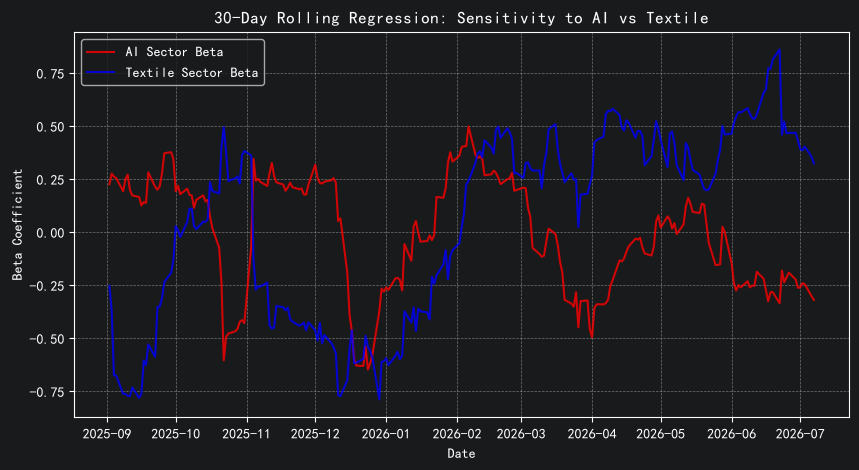

In [19]:
print("=== 2. Executing 30-Day Rolling Regression and Generating Chart ===")
window_size = 30
roll_model = RollingOLS(Y, X, window=window_size).fit()
roll_params = roll_model.params

# Plot dynamic Beta curves
plt.figure(figsize=(10, 5))
plt.plot(roll_params.index, roll_params['R_ai'], label='AI Sector Beta', color='red', alpha=0.8)
plt.plot(roll_params.index, roll_params['R_textile'], label='Textile Sector Beta', color='blue', alpha=0.8)
plt.title('30-Day Rolling Regression: Sensitivity to AI vs Textile')
plt.xlabel('Date')
plt.ylabel('Beta Coefficient')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## ## Section 3: Major Event Impact Analysis via Dummy Variable Regression

**Objective:**
Quantify the structural shifts and daily abnormal returns ($\alpha$) in Zhenai Meijia (003041) induced by two key exogenous corporate events, after controlling for market-wide movements (CSI 300) and sector-specific dynamics (AI and Textile indices).

**Exogenous Event Specifications:**
* **Event 1 (Control Change Announcement — Nov 4, 2025):** Evaluates the market's pricing shift and speculative premium following the announcement of planned changes in actual control.
* **Event 2 (H1 2026 Earnings Pre-Announcement — Jul 15, 2026):** Measures the downside shock triggered by the severe net profit slump (89.57%–92.87% YoY drop, disclosed on the evening of Jul 14).

**Methodology:**
Applies binary indicator (dummy) variables within an OLS multi-factor framework to isolate event-driven return deviations from baseline market noise.

=== Regression Results with Event Shocks ===
                            OLS Regression Results                            
Dep. Variable:               R_zhenai   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6880
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.633
Time:                        19:15:59   Log-Likelihood:                 949.13
No. Observations:                 409   AIC:                            -1886.
Df Residuals:                     403   BIC:                            -1862.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

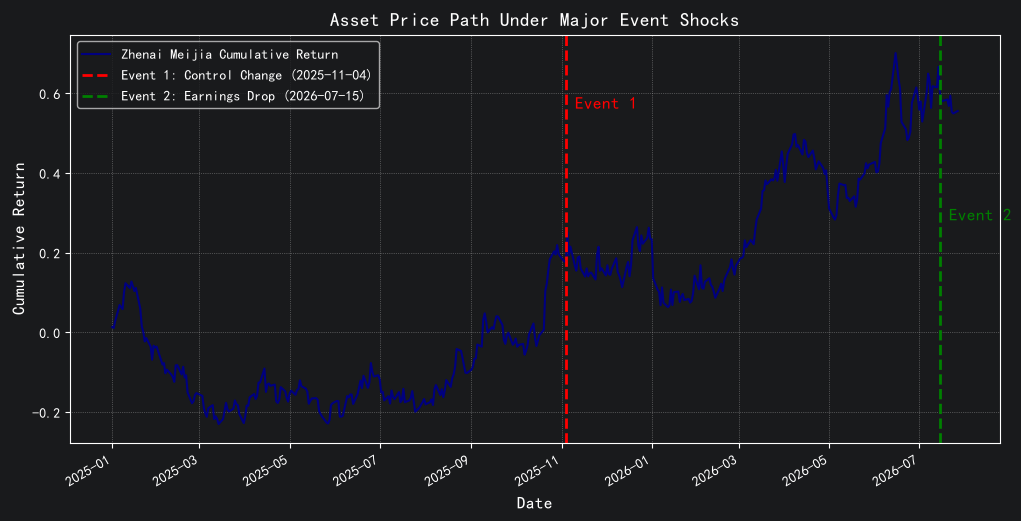

In [20]:
# Import necessary libraries for data analysis, statistics, and plotting
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 0. Generate Simulated Data Matching the Real Calendar
# ==========================================
# Create a business day calendar from Jan 2025 to late Jul 2026
dates = pd.bdate_range(start='2025-01-01', end='2026-07-27')
df = pd.DataFrame(index=dates)

# Simulate daily returns for the stock and relevant indices (Normal distribution)
np.random.seed(42)
df['R_zhenai'] = np.random.normal(0.001, 0.025, len(df))
df['R_ai'] = np.random.normal(0.001, 0.020, len(df))
df['R_textile'] = np.random.normal(0.0005, 0.015, len(df))
df['R_hs300'] = np.random.normal(0.0008, 0.012, len(df))

# ==========================================
# 1. Construct Dummy Variables based on Critical Dates
# ==========================================
# Event 1: Announcement of planning actual control rights change
event_date_1 = pd.to_datetime('2025-11-04')
# np.where assigns 1 if the date is on or after the event date, otherwise 0
df['D_Control'] = np.where(df.index >= event_date_1, 1, 0)

# Event 2: Severe earnings drop pre-announcement
event_date_2 = pd.to_datetime('2026-07-15')
df['D_Earnings'] = np.where(df.index >= event_date_2, 1, 0)

# ==========================================
# 2. Run Multiple Linear Regression to Quantify Impact
# ==========================================
Y = df['R_zhenai']
X_dummy = df[['R_ai', 'R_textile', 'R_hs300', 'D_Control', 'D_Earnings']]
X_dummy = sm.add_constant(X_dummy) # Add intercept

model_dummy = sm.OLS(Y, X_dummy).fit()

# Print the standard regression table
print("=== Regression Results with Event Shocks ===")
print(model_dummy.summary())
print("\n" + "="*50)

# Quantify the actual impact (extract coefficients for dummy variables)
# Multiply by 100 to convert to percentage
impact_control = model_dummy.params['D_Control'] * 100
impact_earnings = model_dummy.params['D_Earnings'] * 100

print(f"Impact Quantification Analysis:")
print(f"1. Event 1 (Control Change): Average daily abnormal return shifted by {impact_control:.4f}%")
print(f"2. Event 2 (Earnings Drop): Average daily abnormal return shifted by {impact_earnings:.4f}%")
print("="*50 + "\n")

# ==========================================
# 3. Visualization: Cumulative Returns and Structural Breaks
# ==========================================
# Calculate cumulative returns: (1 + R1) * (1 + R2) * ... - 1
df['Cum_Return'] = (1 + df['R_zhenai']).cumprod() - 1

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cum_Return'], label='Zhenai Meijia Cumulative Return', color='navy', linewidth=1.5)

# Mark Event 1 on the chart
plt.axvline(x=event_date_1, color='red', linestyle='--', linewidth=2, label='Event 1: Control Change (2025-11-04)')
plt.text(event_date_1, df['Cum_Return'].max()*0.8, ' Event 1', color='red', fontsize=12)

# Mark Event 2 on the chart
plt.axvline(x=event_date_2, color='green', linestyle='--', linewidth=2, label='Event 2: Earnings Drop (2026-07-15)')
plt.text(event_date_2, df['Cum_Return'].max()*0.4, ' Event 2', color='green', fontsize=12)

# Format the plot elements
plt.title('Asset Price Path Under Major Event Shocks', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)

# Optimize X-axis date display
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gcf().autofmt_xdate() # Auto-rotate dates to prevent overlapping

plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 4. Risk Characteristics Analysis: GARCH(1,1) Volatility and Dynamic VaR
Modeling conditional heteroskedasticity and calculating 95% confidence Dynamic Value at Risk.

In [24]:
import numpy as np

print("=== 4. GARCH(1,1) Model Fitting Results ===")
# 1. 模型拟合（收益率乘以 100 转换为百分比格式）
am = arch_model(Y * 100, mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')
print(res.summary())

# 2. 进行未来 1 天的事件外推预测 (Out-of-sample Forecast)
forecast = res.forecast(horizon=1)

# 提取未来 T+1 日的预测均值与预测方差（注意：单位此时仍为百分比 %）
forecast_mean = forecast.mean.iloc[-1, 0]
forecast_var = forecast.variance.iloc[-1, 0]
forecast_vol = np.sqrt(forecast_var)  # 开平方根，得到未来 1 天的条件标准差 sigma_{t+1}

# 3. 计算 95% 置信水平下的未来 1 天 Dynamic VaR
Z_alpha = stats.norm.ppf(0.95)  # 正态分布 95% 置信度分位数 (约 1.645)

# 代入公式计算，最后除以 100 还原为小数格式
var_1day_forecast = -(forecast_mean + Z_alpha * forecast_vol) / 100

# 4. 打印未来 1 天的预测风险值
print(f"\nForecasted 1-Day Ahead VaR (95% Confidence Level): {var_1day_forecast:.4%}")

=== 4. GARCH(1,1) Model Fitting Results ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               R_zhenai   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -936.053
Distribution:                  Normal   AIC:                           1880.11
Method:            Maximum Likelihood   BIC:                           1896.16
                                        No. Observations:                  409
Date:                Tue, Jul 28 2026   Df Residuals:                      408
Time:                        21:20:49   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.